# Batch Size Experiment: MCL1 MMGBSA and Vina

Tests how batch acquisition size affects BO efficiency.
All conditions use **EI** with a **linear-empirical** surrogate and acquire exactly
**3600 molecules** in total (`n_iter × batch_size = 3600`), so the x-axis is
directly comparable across conditions.

| Condition | Batch size | n\_iter |
|-----------|-----------|--------|
| Sequential (baseline) | 1 | 3600 |
| Batched | 5 | 720 |
| Batched | 10 | 360 |
| Batched | 50 | 72 |
| Batched | 100 | 36 |
| Batched (upper bound) | 600 | 6 |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import seaborn as sns

from utils import load_data

sns.set_style("whitegrid")
sns.set_context("notebook")

plt.rcParams.update({
    'svg.fonttype': 'none',
    'font.size': 16,
    "lines.linewidth": 2,
    "axes.labelsize": 18,
    "axes.titlesize": 22,
})

In [ ]:
RUNS_DIR = Path("../bayesian_optimization_results")
K_RATIO  = 0.01

# New batch-size runs (results land in RUNS_DIR after the HTCondor jobs finish)
BATCH_SIZES = [5, 10, 50, 100]

# Dataset config: display name → {sequential DB, batch-600 DB, runs-dir prefix}
DATASETS = {
    "MMGBSA": {
        "sequential": Path("../bayesian_optimization_results/mcl1_mmgbsa_sequential.sqlite"),
        "batch600":   Path("../bayesian_optimization_results/mcl1_mmgbsa_batch600.sqlite"),
        "prefix":     "mcl1_mmgbsa",
    },
    "Vina (Docking)": {
        "sequential": Path("../bayesian_optimization_results/mcl1_vina_sequential.sqlite"),
        "batch600":   Path("../bayesian_optimization_results/mcl1_vina_batch600.sqlite"),
        "prefix":     "mcl1_vina",
    },
}

EMBEDDING_ORDER = ["ChemBERTa-2", "MolFormer", "Morgan Fingerprint"]

# Color and linewidth: evenly spaced by index for consistent visual separation
ALL_BATCH_SIZES = [1] + BATCH_SIZES + [600]
idx_norm = np.linspace(0, 1, len(ALL_BATCH_SIZES))

LW_MIN, LW_MAX = 1.0, 3.0
BATCH_COLORS = {b: plt.cm.viridis(v) for b, v in zip(ALL_BATCH_SIZES, idx_norm)}
BATCH_LW     = {b: LW_MIN + v * (LW_MAX - LW_MIN) for b, v in zip(ALL_BATCH_SIZES, idx_norm)}

# Linestyle: solid → dotted as batch size increases
BATCH_STYLES = {
    1:   "-",
    5:   (0, (5, 1)),         # densely dashed
    10:  "--",                 # dashed
    50:  "-.",                 # dash-dot
    100: (0, (3, 1, 1, 1)),   # dense dash-dot
    600: ":",                  # dotted
}

# Markers: only for batch >= 50
BATCH_MARKERS = {1: None, 5: None, 10: None, 50: "o", 100: "o", 600: "D"}
BATCH_LABELS  = {
    1:   "Batch=1",
    5:   "Batch=5",
    10:  "Batch=10",
    50:  "Batch=50",
    100: "Batch=100",
    600: "Batch=600",
}

In [3]:
def prep(df: pd.DataFrame, batch_size: int) -> pd.DataFrame:
    """Filter to linear surrogate and add molecules-queried column.

    :param pd.DataFrame df: Raw DataFrame from load_data.
    :param int batch_size: Number of molecules acquired per BO iteration.
    :return: Filtered DataFrame with 'Molecules Queried' and 'Batch Size' columns.
    :rtype: pd.DataFrame
    """
    df = df[df["Surrogate"] == "Linear"].copy()
    df["Molecules Queried"] = df["Iteration"] * batch_size
    df["Batch Size"] = batch_size
    return df


def load_all(dataset_name: str, cfg: dict) -> pd.DataFrame:
    """Load sequential, intermediate-batch, and batch=600 runs for one dataset.

    :param str dataset_name: Human-readable dataset label.
    :param dict cfg: Entry from DATASETS with 'sequential', 'batch600', 'prefix' keys.
    :return: Combined DataFrame with all batch conditions for this dataset.
    :rtype: pd.DataFrame
    """
    dfs = []

    # Sequential baseline (batch=1)
    df, top_k, _ = load_data(str(cfg["sequential"]), k_ratio=K_RATIO)
    dfs.append(prep(df, batch_size=1))

    # Intermediate batch sizes (new runs)
    for b in BATCH_SIZES:
        db = RUNS_DIR / f"{cfg['prefix']}_batch{b}.sqlite"
        if not db.exists():
            print(f"  Missing: {db}")
            continue
        df, top_k, _ = load_data(str(db), k_ratio=K_RATIO)
        dfs.append(prep(df, batch_size=b))

    # Batch=600 upper bound
    df, top_k, _ = load_data(str(cfg["batch600"]), k_ratio=K_RATIO)
    dfs.append(prep(df, batch_size=600))

    combined = pd.concat(dfs, ignore_index=True)
    combined["Dataset"] = dataset_name
    combined["k"] = len(top_k)

    # experiment_id values collide across DBs (each DB starts from 1), so
    # nunique() on the merged frame is meaningless. Report per-batch-size instead.
    batches_found = sorted(combined["Batch Size"].unique())
    n_emb = combined.groupby("Batch Size")["Embedding Model"].nunique()
    print(f"{dataset_name}: batch sizes {batches_found}, embeddings per condition: {n_emb.to_dict()}")
    return combined


all_data = pd.concat(
    [load_all(name, cfg) for name, cfg in DATASETS.items()],
    ignore_index=True,
)
print(f"\nTop-{K_RATIO*100:.0f}% threshold: {all_data['k'].iloc[0]} molecules")

MMGBSA: batch sizes [1, 5, 10, 50, 100, 600], embeddings per condition: {1: 3, 5: 3, 10: 3, 50: 3, 100: 3, 600: 3}
Vina (Docking): batch sizes [1, 5, 10, 50, 100, 600], embeddings per condition: {1: 3, 5: 3, 10: 3, 50: 3, 100: 3, 600: 3}

Top-1% threshold: 593 molecules


## Top-1% Retrieval Curves

Rows: dataset. Columns: embedding model.  
Color: batch size (blue = sequential, red = batch=600).  
Markers: filled circles for intermediate batches, diamonds for batch=600; no markers for sequential.  
X-axis: **total molecules queried** (`Iteration × batch_size`), budget-comparable across all conditions.

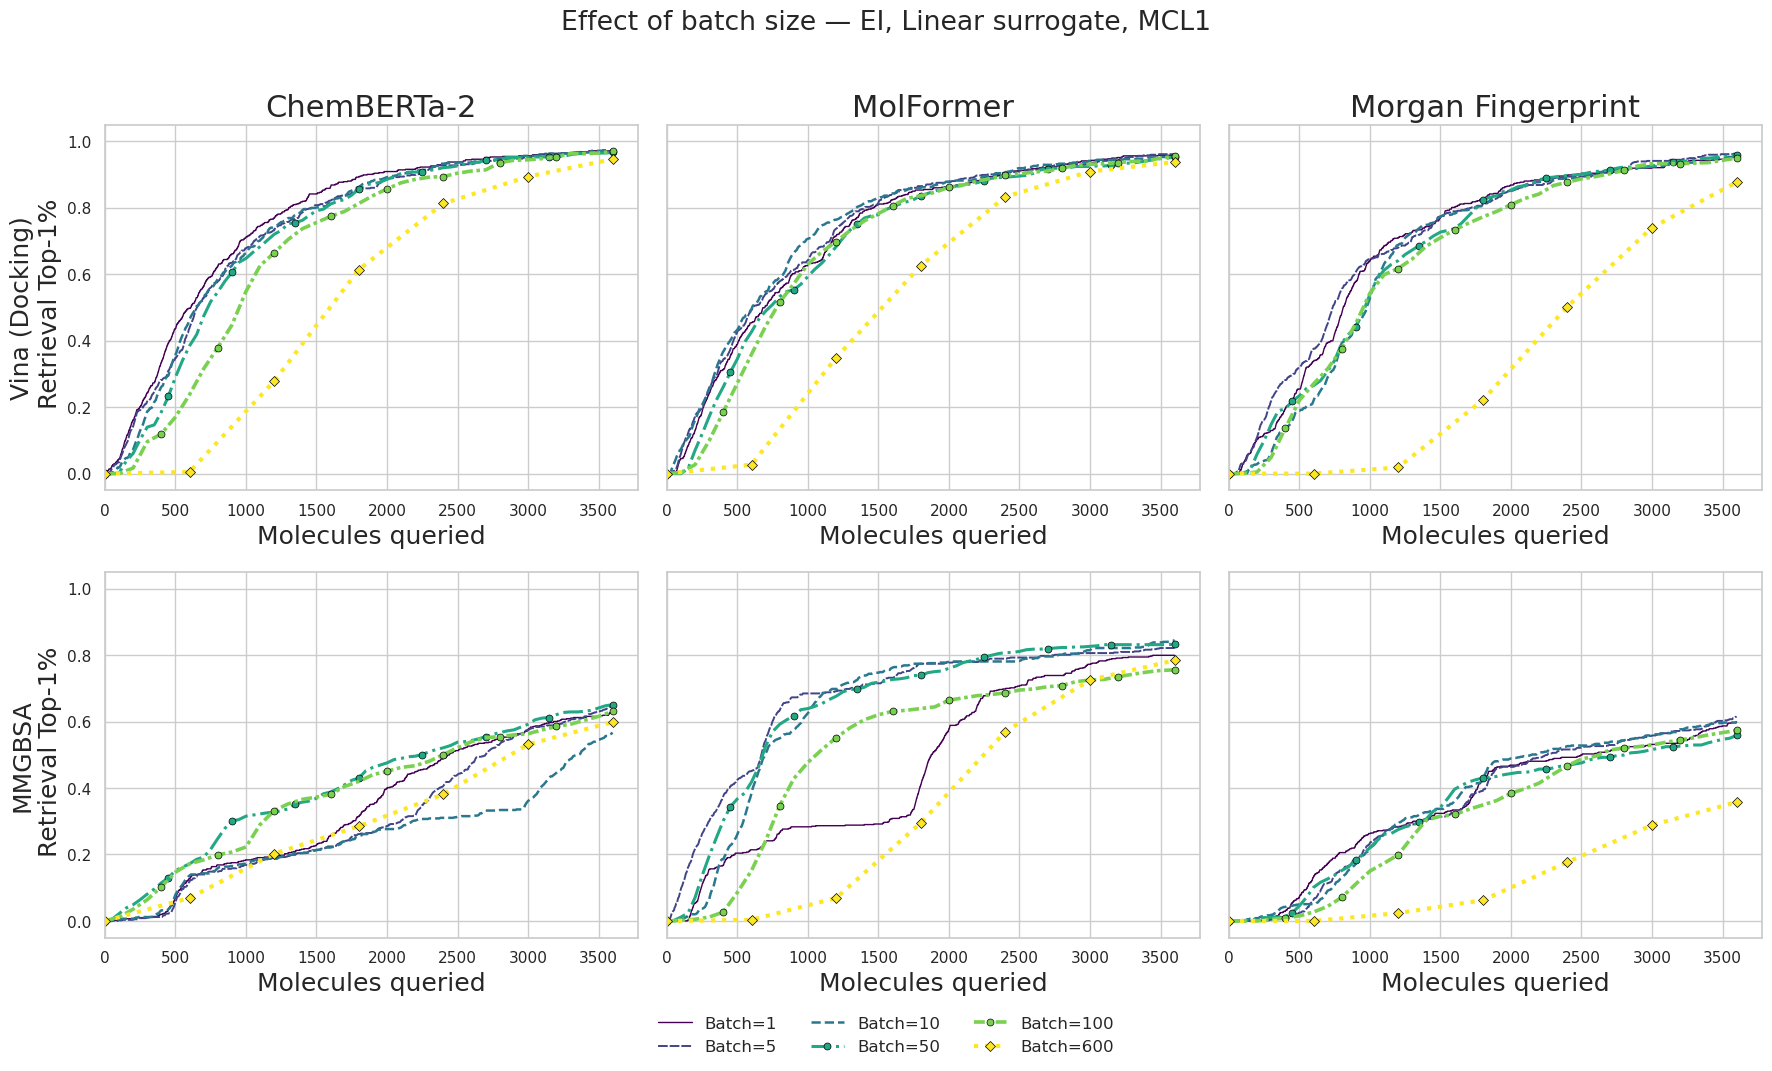

In [4]:
dataset_order = sorted(list(DATASETS.keys()))[::-1]

fig, axes = plt.subplots(
    len(dataset_order), len(EMBEDDING_ORDER),
    figsize=(18, 5 * len(dataset_order)),
    sharey="row",
)

for row, dataset_name in enumerate(dataset_order):
    dataset_df = all_data[all_data["Dataset"] == dataset_name]
    k = dataset_df["k"].iloc[0]

    for col, embedding in enumerate(EMBEDDING_ORDER):
        ax = axes[row, col]
        subset = dataset_df[dataset_df["Embedding Model"] == embedding]

        for batch in ALL_BATCH_SIZES:
            group = subset[subset["Batch Size"] == batch]
            if group.empty:
                continue

            curve = group.groupby("Molecules Queried")["is_top_k_cum"].max() / k

            n_pts = len(curve)
            markevery = max(1, n_pts // 8) if BATCH_MARKERS[batch] else None

            ax.plot(
                curve.index,
                curve.values,
                color=BATCH_COLORS[batch],
                linestyle=BATCH_STYLES[batch],
                linewidth=BATCH_LW[batch],
                marker=BATCH_MARKERS[batch],
                markevery=markevery,
                markersize=5,
                markeredgecolor="k",
                markeredgewidth=0.5,
                label=BATCH_LABELS[batch],
            )

        if row == 0:
            ax.set_title(embedding)
        if col == 0:
            ax.set_ylabel(f"{dataset_name}\n Retrieval Top-{K_RATIO*100:.0f}%")
        ax.set_xlabel("Molecules queried")
        ax.set_xlim(left=0)
        ax.set_ylim(-0.05, 1.05)

# Legend: one entry per batch size
handles = []
for batch in ALL_BATCH_SIZES:
    handles.append(
        mlines.Line2D(
            [0], [0],
            color=BATCH_COLORS[batch],
            linewidth=BATCH_LW[batch],
            linestyle=BATCH_STYLES[batch],
            marker=BATCH_MARKERS[batch],
            markersize=5,
            markeredgecolor="k",
            markeredgewidth=0.5,
            label=BATCH_LABELS[batch],
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
    fontsize=12,
)
fig.suptitle("Effect of batch size — EI, Linear surrogate, MCL1", y=1.01)
plt.tight_layout()
plt.savefig("figures/batch_size_retrieval.pdf", dpi=300, bbox_inches="tight")
plt.savefig("figures/batch_size_retrieval.svg", bbox_inches="tight")
plt.show()

## Final Retrieval Rate (Summary Table)

Fraction of top-1% molecules found after all 3600 molecules queried, averaged over
experiment repetitions, per embedding model.

In [5]:
k = all_data["k"].iloc[0]

final = (
    all_data
    .groupby(["experiment_id", "Dataset", "Batch Size", "Embedding Model"])["is_top_k"]
    .sum()
    .div(k)
    .reset_index()
    .rename(columns={"is_top_k": "Retrieval Rate"})
    .groupby(["Dataset", "Batch Size", "Embedding Model"])["Retrieval Rate"]
    .mean()
    .unstack("Embedding Model")
    .reindex(columns=EMBEDDING_ORDER)
    .reindex(ALL_BATCH_SIZES, level="Batch Size")
    .round(3)
)
final

Embedding Model            ChemBERTa-2  MolFormer  Morgan Fingerprint
Dataset        Batch Size                                            
MMGBSA         1                 0.627      0.799               0.599
               5                 0.646      0.821               0.308
               10                0.567      0.845               0.323
               50                0.651      0.833               0.558
               100               0.631      0.755               0.567
               600               0.599      0.784               0.358
Vina (Docking) 1                 0.971      0.958               0.960
               5                 0.970      0.961               0.963
               10                0.975      0.953               0.953
               50                0.966      0.953               0.958
               100               0.970      0.954               0.949
               600               0.946      0.938               0.877

## Early-Phase Retrieval

Cumulative top-1% found after the first **360 molecules** queried (10% of budget).
Tests whether larger batches sacrifice early exploitation.

In [6]:
EARLY_CUTOFF = 360  # 10% of 3600-molecule budget

early = (
    all_data[all_data["Molecules Queried"] <= EARLY_CUTOFF]
    .groupby(["experiment_id", "Dataset", "Batch Size", "Embedding Model"])["is_top_k"]
    .sum()
    .div(k)
    .reset_index()
    .rename(columns={"is_top_k": f"Retrieval Rate (≤{EARLY_CUTOFF} queries)"})
    .groupby(["Dataset", "Batch Size", "Embedding Model"])[f"Retrieval Rate (≤{EARLY_CUTOFF} queries)"]
    .mean()
    .unstack("Embedding Model")
    .reindex(columns=EMBEDDING_ORDER)
    .reindex(ALL_BATCH_SIZES, level="Batch Size")
    .round(3)
)
early

Embedding Model            ChemBERTa-2  MolFormer  Morgan Fingerprint
Dataset        Batch Size                                            
MMGBSA         1                 0.013      0.162               0.024
               5                 0.012      0.339               0.005
               10                0.019      0.152               0.035
               50                0.096      0.250               0.012
               100               0.064      0.012               0.005
               600               0.000      0.000               0.000
Vina (Docking) 1                 0.285      0.292               0.167
               5                 0.256      0.305               0.265
               10                0.221      0.329               0.123
               50                0.147      0.221               0.189
               100               0.096      0.099               0.049
               600               0.000      0.000               0.000